<a href="https://www.kaggle.com/code/omborse771924/96-years-of-commonwealth-games-history-eda?scriptVersionId=340638740" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rupsarroy/96-years-of-commonwealth-games-history-19302026/Commonwealth_Medalists_1930_2026.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/rupsarroy/96-years-of-commonwealth-games-history-19302026/Commonwealth_Medalists_1930_2026.csv')

In [3]:
df.head()

,Year,Date,Sport,Event,Event_gender,Team,Country_Code,Athlete,Gender,Medal,CGA,Host_City,Games,Season
0,1930,16–23 August 1930,Swimming,100 yd freestyle,Men,Canada,CAN,Munroe Bourne,Male,Gold,CAN,Hamilton,1930 British Empire Games,Summer
1,1930,16–23 August 1930,Swimming,100 yd freestyle,Men,England,ENG,Norman Brooks,Male,Silver,ENG,Hamilton,1930 British Empire Games,Summer
2,1930,16–23 August 1930,Swimming,100 yd freestyle,Men,Canada,CAN,Bert Gibson,Male,Bronze,CAN,Hamilton,1930 British Empire Games,Summer
3,1930,16–23 August 1930,Swimming,400 yd freestyle,Men,Australia,AUS,Noel Ryan,Male,Gold,AUS,Hamilton,1930 British Empire Games,Summer
4,1930,16–23 August 1930,Swimming,400 yd freestyle,Men,New Zealand,NZL,Gordon Bridson,Male,Silver,NZL,Hamilton,1930 British Empire Games,Summer


In [4]:
df.tail()

,Year,Date,Sport,Event,Event_gender,Team,Country_Code,Athlete,Gender,Medal,CGA,Host_City,Games,Season
11657,2026,24-Jul-26,Para Powerlifting,Lightweight,Women,Nigeria,NGR,Esther Oyema,Female,Silver,NGR,Glasgow,2026 Commonwealth Games,Summer
11658,2026,24-Jul-26,Para Powerlifting,Lightweight,Women,England,ENG,Olivia Broome,Female,Bronze,ENG,Glasgow,2026 Commonwealth Games,Summer
11659,2026,24-Jul-26,Para Powerlifting,Heavyweight,Women,Nigeria,NGR,Folashade Oluwafemiayo,Female,Gold,NGR,Glasgow,2026 Commonwealth Games,Summer
11660,2026,24-Jul-26,Para Powerlifting,Heavyweight,Women,Nigeria,NGR,Rita Ferdinand,Female,Silver,NGR,Glasgow,2026 Commonwealth Games,Summer
11661,2026,24-Jul-26,Para Powerlifting,Heavyweight,Women,Australia,AUS,Hani Watson,Female,Bronze,AUS,Glasgow,2026 Commonwealth Games,Summer


In [5]:
df.info

<bound method DataFrame.info of        Year               Date              Sport             Event  \
0      1930  16–23 August 1930           Swimming  100 yd freestyle   
1      1930  16–23 August 1930           Swimming  100 yd freestyle   
2      1930  16–23 August 1930           Swimming  100 yd freestyle   
3      1930  16–23 August 1930           Swimming  400 yd freestyle   
4      1930  16–23 August 1930           Swimming  400 yd freestyle   
...     ...                ...                ...               ...   
11657  2026          24-Jul-26  Para Powerlifting       Lightweight   
11658  2026          24-Jul-26  Para Powerlifting       Lightweight   
11659  2026          24-Jul-26  Para Powerlifting       Heavyweight   
11660  2026          24-Jul-26  Para Powerlifting       Heavyweight   
11661  2026          24-Jul-26  Para Powerlifting       Heavyweight   

      Event_gender         Team Country_Code                 Athlete  Gender  \
0              Men       Canada    

In [6]:
df.describe()

,Year
count,11662.000000
mean,1993.011147
std,24.988100
min,1930.000000
25%,1974.000000
50%,1998.000000
75%,2014.000000
max,2026.000000


In [7]:
df.isnull()

,Year,Date,Sport,Event,Event_gender,Team,Country_Code,Athlete,Gender,Medal,CGA,Host_City,Games,Season
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11657,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11658,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11659,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11660,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Year            0
Date            0
Sport           0
Event           0
Event_gender    0
Team            0
Country_Code    0
Athlete         0
Gender          0
Medal           0
CGA             0
Host_City       0
Games           0
Season          0
dtype: int64

In [9]:
df.duplicated

<bound method DataFrame.duplicated of        Year               Date              Sport             Event  \
0      1930  16–23 August 1930           Swimming  100 yd freestyle   
1      1930  16–23 August 1930           Swimming  100 yd freestyle   
2      1930  16–23 August 1930           Swimming  100 yd freestyle   
3      1930  16–23 August 1930           Swimming  400 yd freestyle   
4      1930  16–23 August 1930           Swimming  400 yd freestyle   
...     ...                ...                ...               ...   
11657  2026          24-Jul-26  Para Powerlifting       Lightweight   
11658  2026          24-Jul-26  Para Powerlifting       Lightweight   
11659  2026          24-Jul-26  Para Powerlifting       Heavyweight   
11660  2026          24-Jul-26  Para Powerlifting       Heavyweight   
11661  2026          24-Jul-26  Para Powerlifting       Heavyweight   

      Event_gender         Team Country_Code                 Athlete  Gender  \
0              Men       Cana

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Year', 'Date', 'Sport', 'Event', 'Event_gender', 'Team',
       'Country_Code', 'Athlete', 'Gender', 'Medal', 'CGA', 'Host_City',
       'Games', 'Season'],
      dtype='object')

## EDA

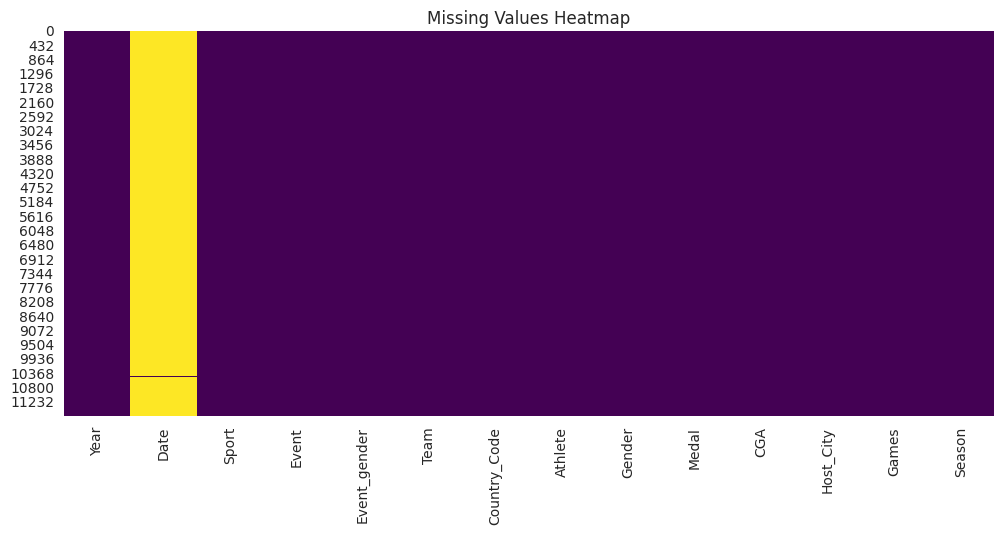

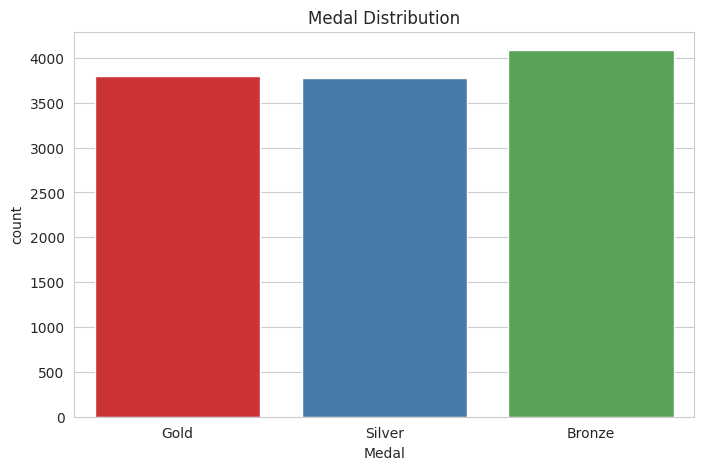

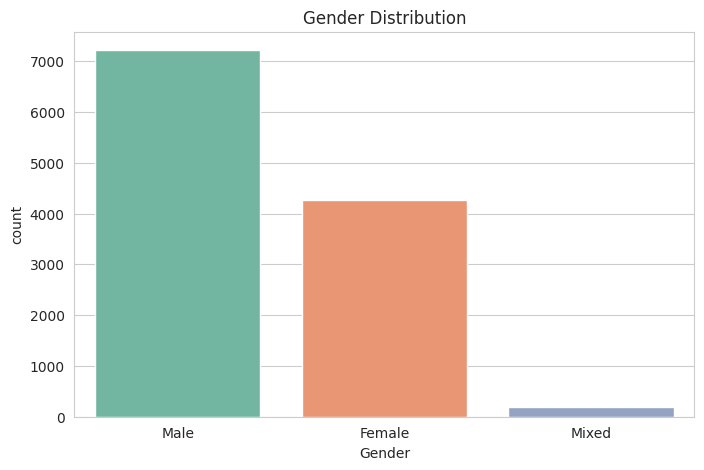

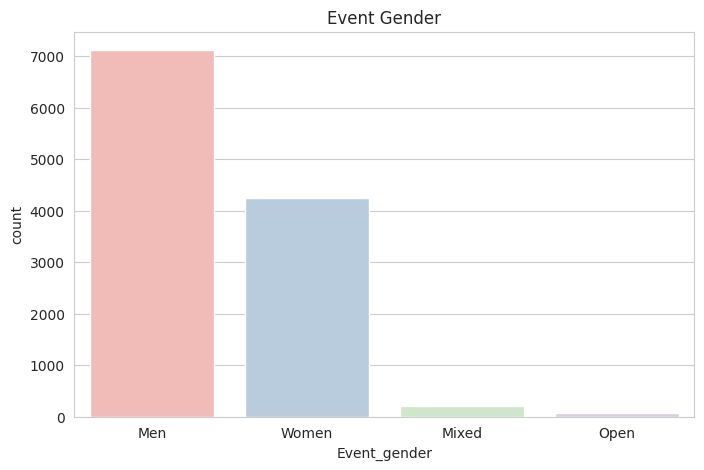

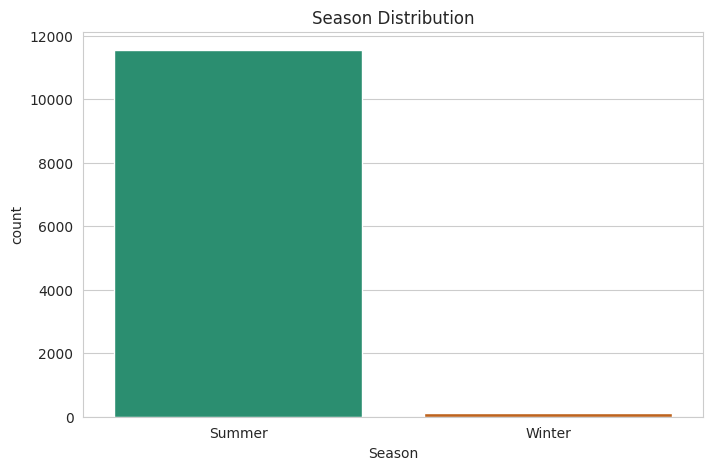

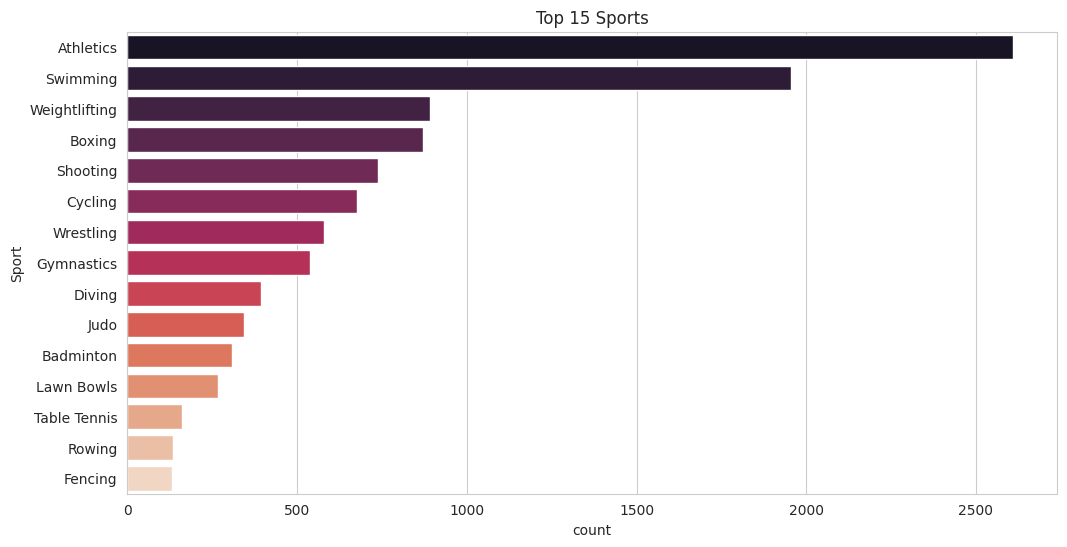

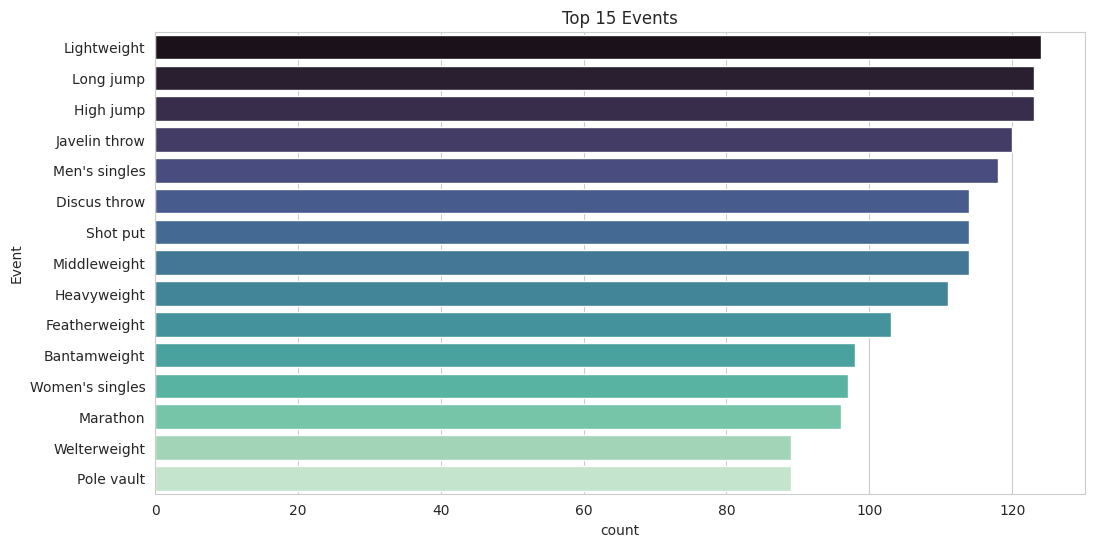

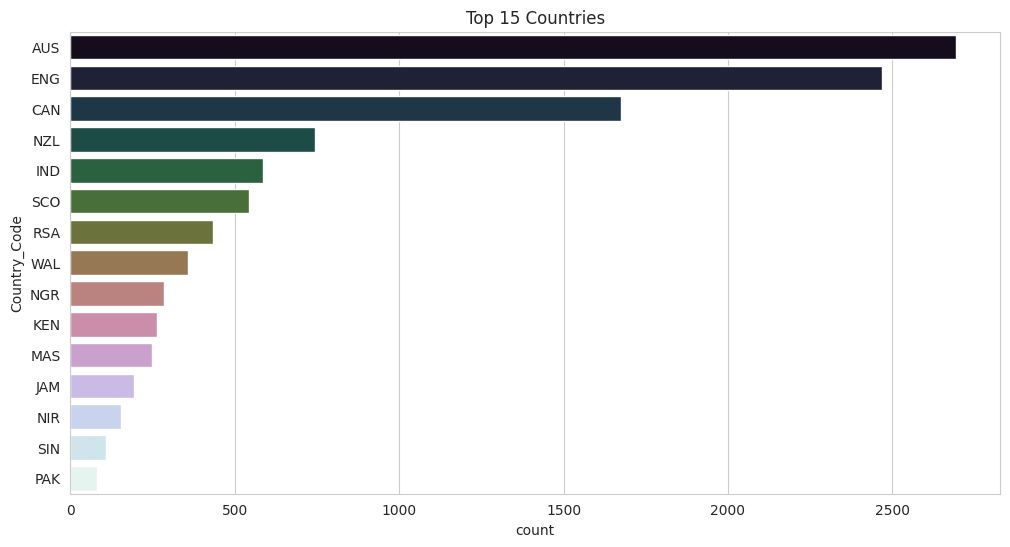

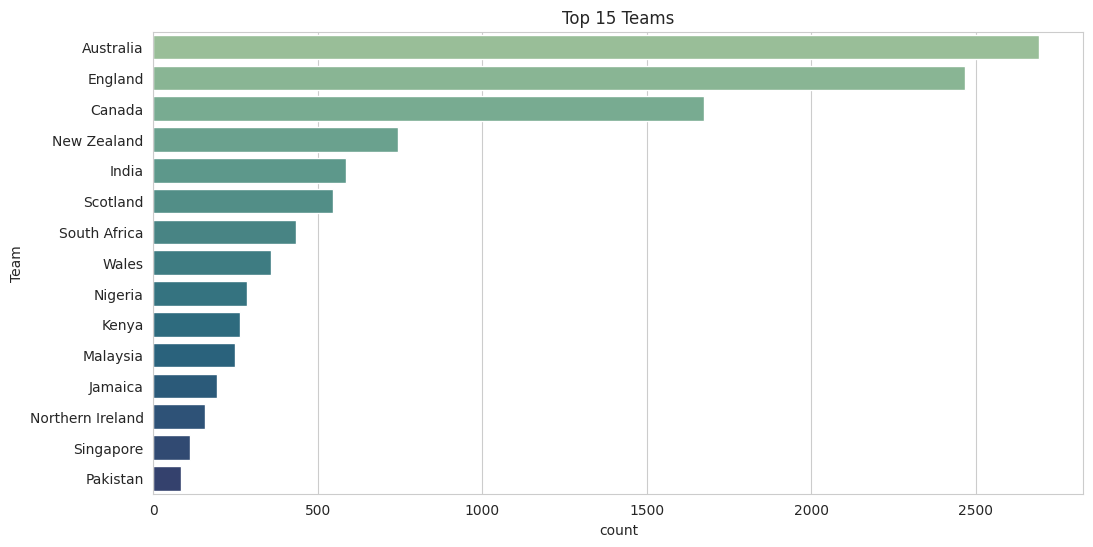

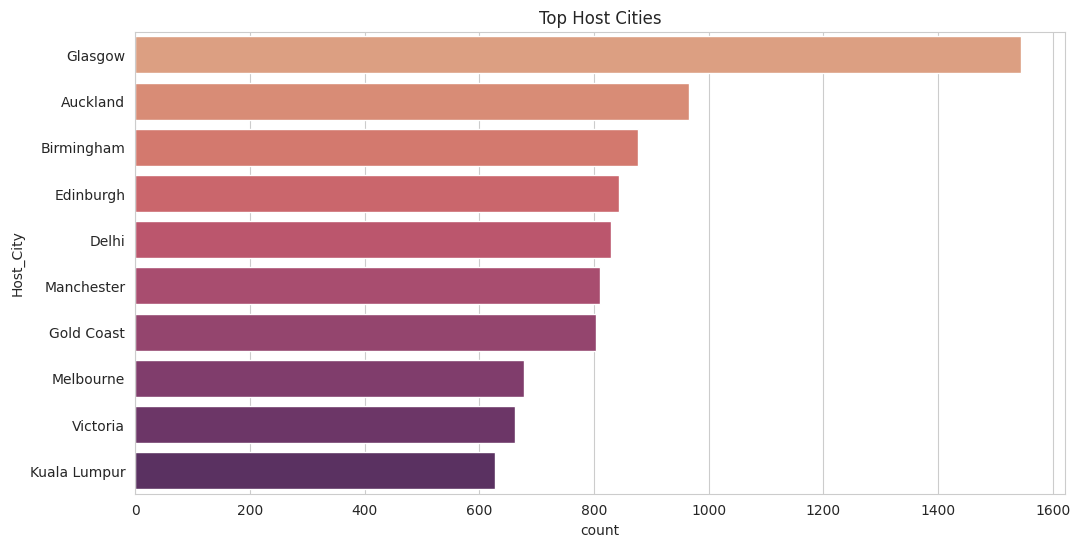

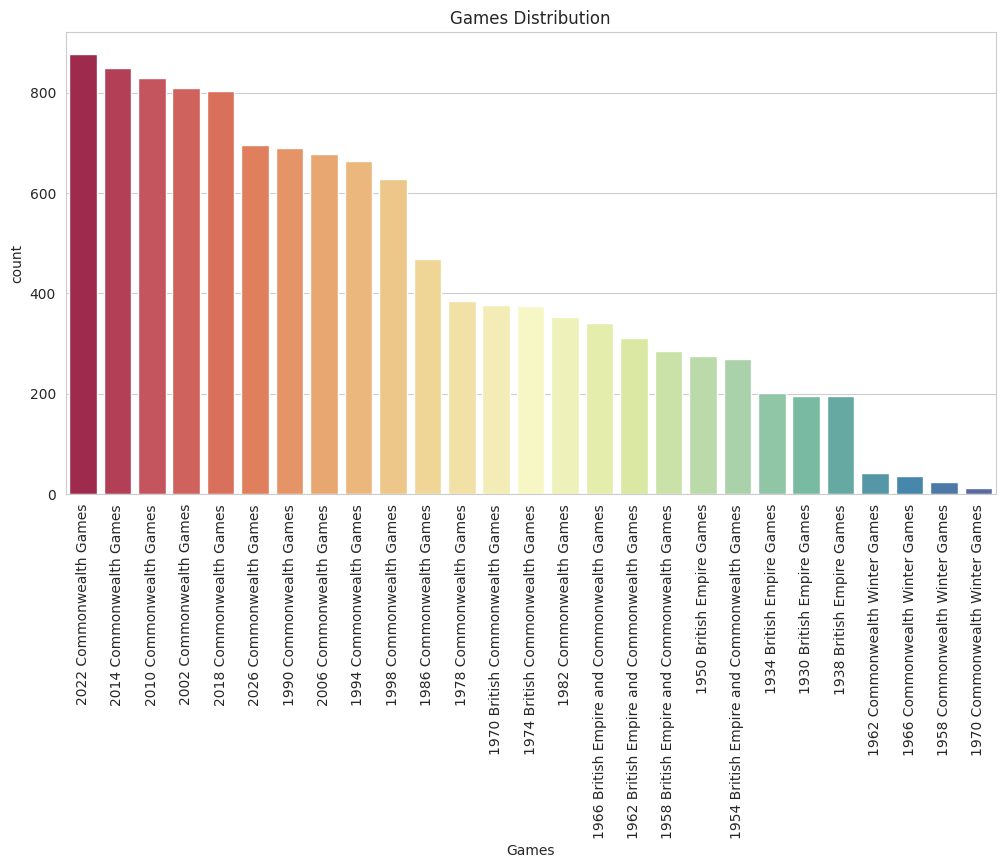

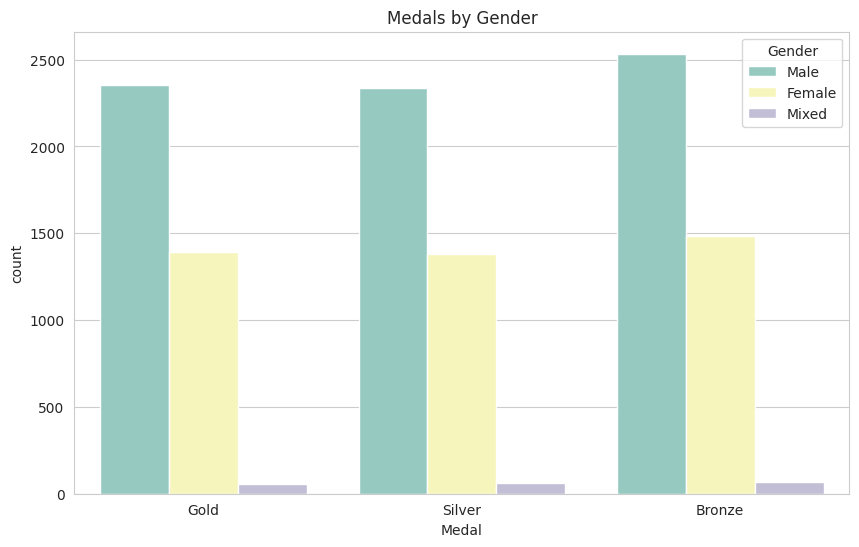

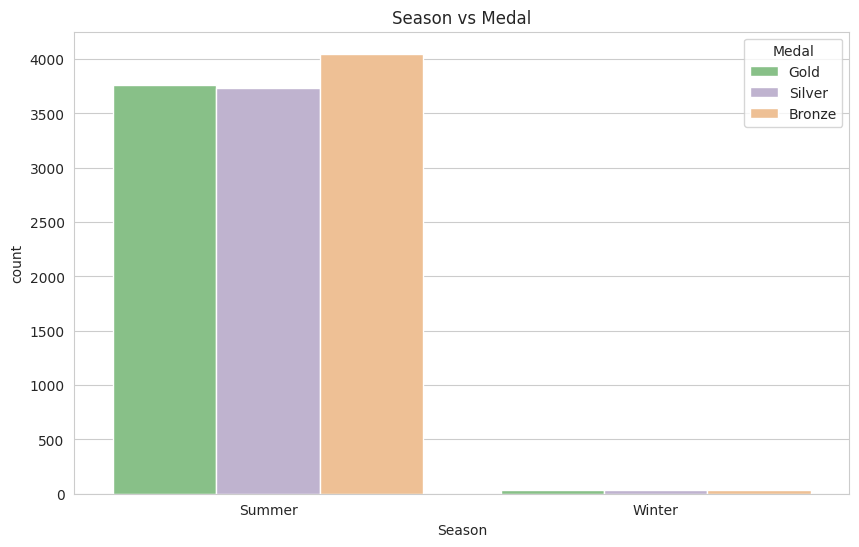

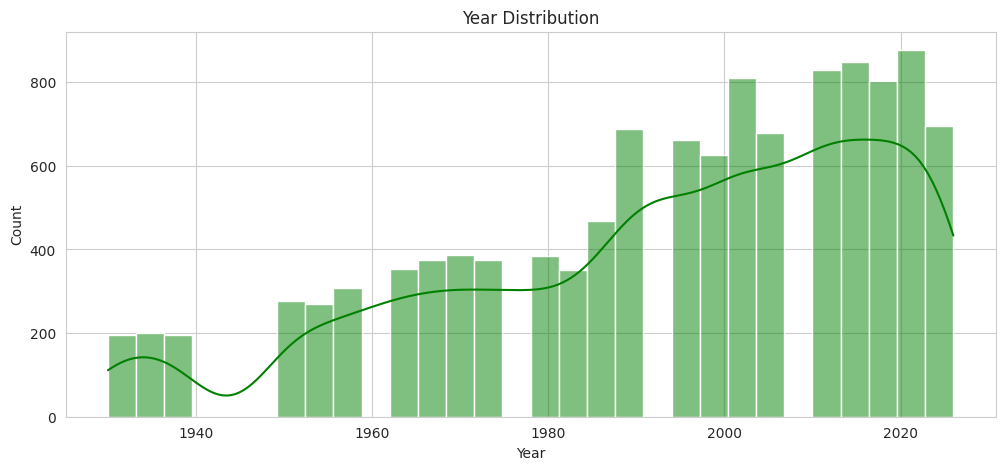

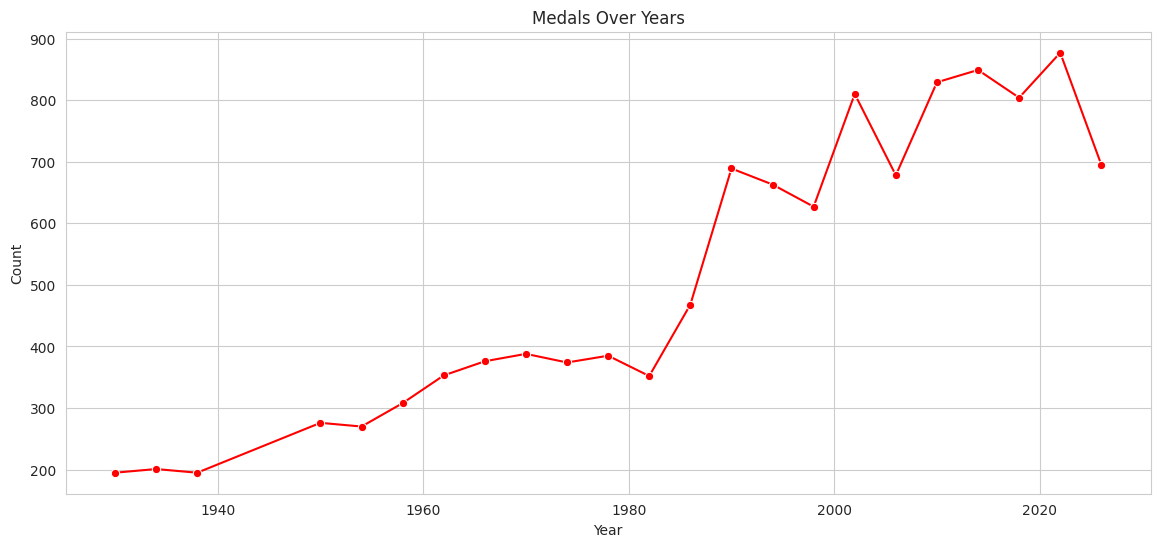

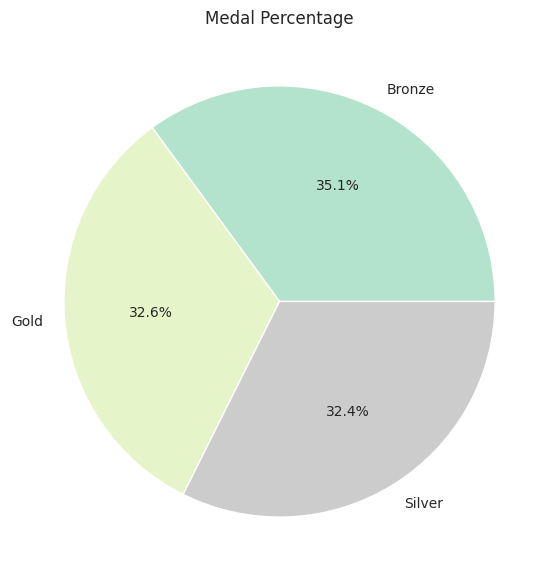

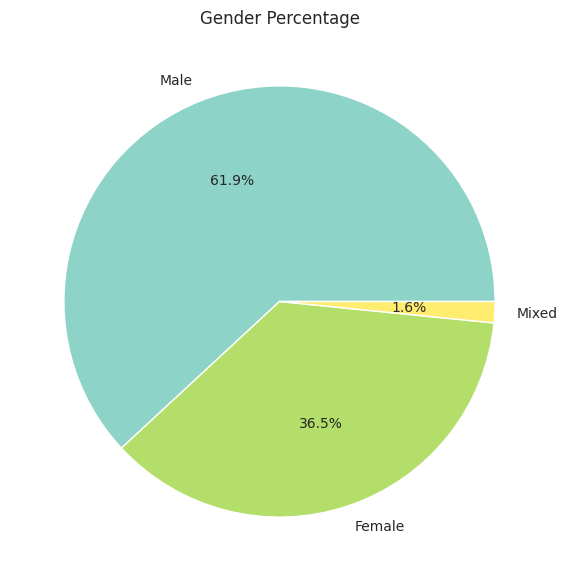

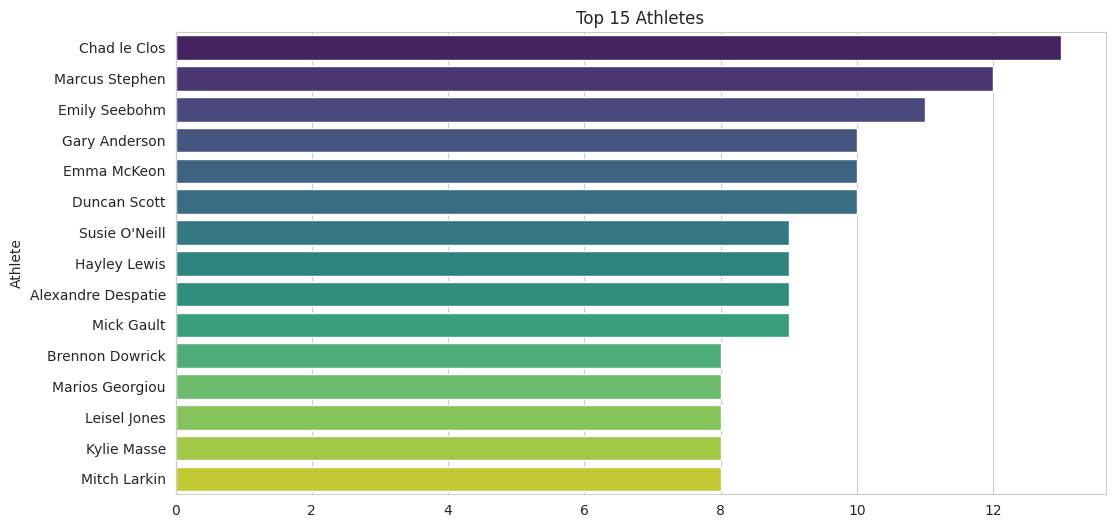

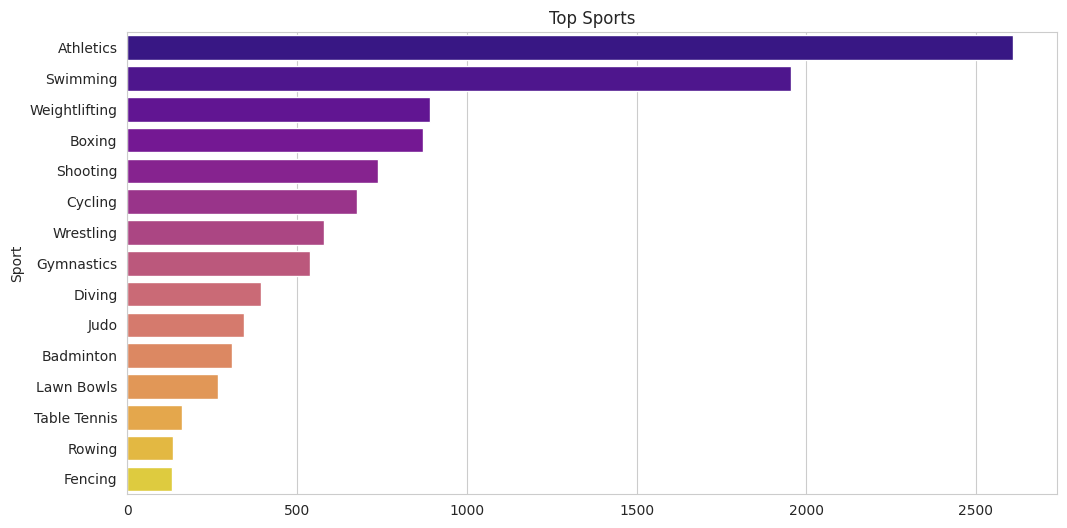

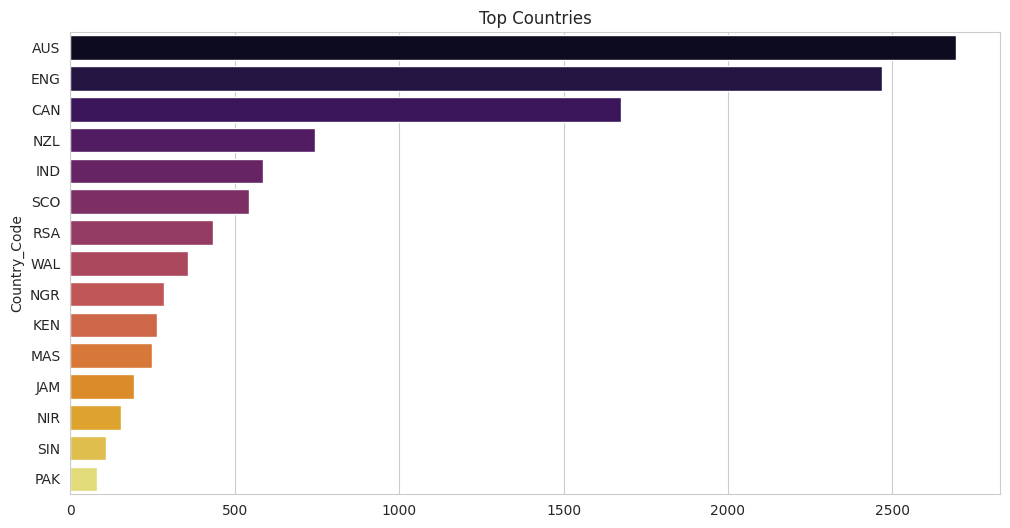

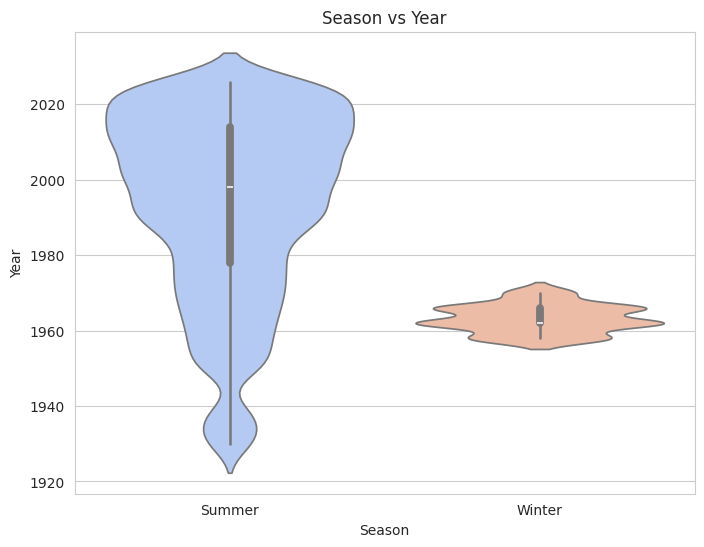

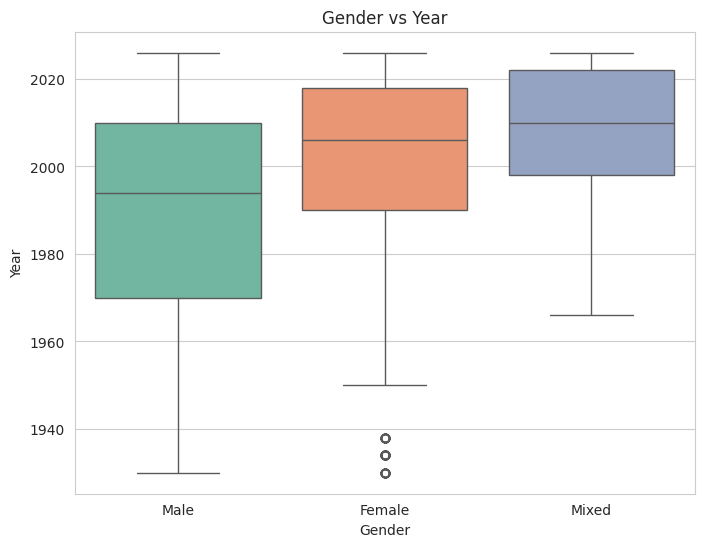

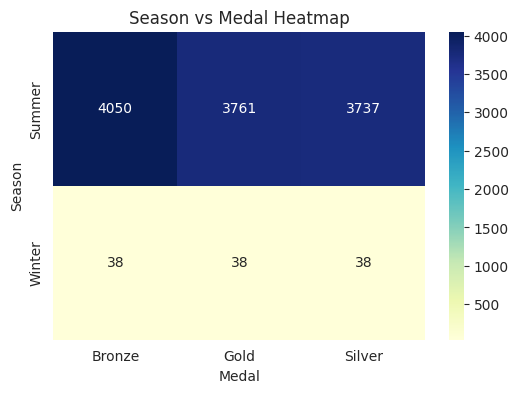

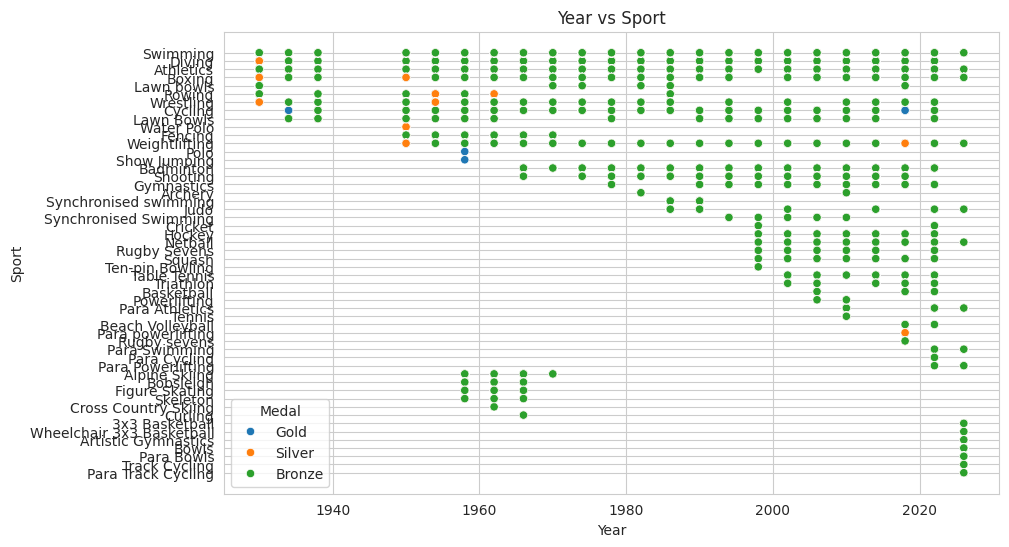

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================
# Style
# =============================================

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,6)

# =============================================
# Convert Date
# =============================================

df["Date"]=pd.to_datetime(df["Date"],errors="coerce")

# =============================================
# Missing Value Heatmap
# =============================================

plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(),cmap="viridis",cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# =============================================
# Medal Distribution
# =============================================

plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Medal",palette="Set1")
plt.title("Medal Distribution")
plt.show()

# =============================================
# Gender Distribution
# =============================================

plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Gender",palette="Set2")
plt.title("Gender Distribution")
plt.show()

# =============================================
# Event Gender
# =============================================

plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Event_gender",palette="Pastel1")
plt.title("Event Gender")
plt.show()

# =============================================
# Season
# =============================================

plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Season",palette="Dark2")
plt.title("Season Distribution")
plt.show()

# =============================================
# Top 15 Sports
# =============================================

plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y="Sport",
    order=df["Sport"].value_counts().head(15).index,
    palette="rocket"
)
plt.title("Top 15 Sports")
plt.show()

# =============================================
# Top 15 Events
# =============================================

plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y="Event",
    order=df["Event"].value_counts().head(15).index,
    palette="mako"
)
plt.title("Top 15 Events")
plt.show()

# =============================================
# Top 15 Countries
# =============================================

plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y="Country_Code",
    order=df["Country_Code"].value_counts().head(15).index,
    palette="cubehelix"
)
plt.title("Top 15 Countries")
plt.show()

# =============================================
# Top 15 Teams
# =============================================

plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y="Team",
    order=df["Team"].value_counts().head(15).index,
    palette="crest"
)
plt.title("Top 15 Teams")
plt.show()

# =============================================
# Top Host Cities
# =============================================

plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y="Host_City",
    order=df["Host_City"].value_counts().head(10).index,
    palette="flare"
)
plt.title("Top Host Cities")
plt.show()

# =============================================
# Games Distribution
# =============================================

plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x="Games",
    order=df["Games"].value_counts().index,
    palette="Spectral"
)
plt.xticks(rotation=90)
plt.title("Games Distribution")
plt.show()

# =============================================
# Medal by Gender
# =============================================

plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x="Medal",
    hue="Gender",
    palette="Set3"
)
plt.title("Medals by Gender")
plt.show()

# =============================================
# Medal by Season
# =============================================

plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x="Season",
    hue="Medal",
    palette="Accent"
)
plt.title("Season vs Medal")
plt.show()

# =============================================
# Year Distribution
# =============================================

plt.figure(figsize=(12,5))
sns.histplot(
    df["Year"],
    bins=30,
    kde=True,
    color="green"
)
plt.title("Year Distribution")
plt.show()

# =============================================
# Medals per Year
# =============================================

year_medals=df.groupby("Year").size().reset_index(name="Count")

plt.figure(figsize=(14,6))
sns.lineplot(
    data=year_medals,
    x="Year",
    y="Count",
    marker="o",
    color="red"
)
plt.title("Medals Over Years")
plt.show()

# =============================================
# Pie Chart Medal
# =============================================

plt.figure(figsize=(7,7))
df["Medal"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Pastel2"
)
plt.ylabel("")
plt.title("Medal Percentage")
plt.show()

# =============================================
# Pie Chart Gender
# =============================================

plt.figure(figsize=(7,7))
df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Set3"
)
plt.ylabel("")
plt.title("Gender Percentage")
plt.show()

# =============================================
# Athlete Frequency
# =============================================

top_athletes=df["Athlete"].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_athletes.values,
    y=top_athletes.index,
    palette="viridis"
)
plt.title("Top 15 Athletes")
plt.show()

# =============================================
# Sport Frequency
# =============================================

sport=df["Sport"].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(
    x=sport.values,
    y=sport.index,
    palette="plasma"
)
plt.title("Top Sports")
plt.show()

# =============================================
# Country Frequency
# =============================================

country=df["Country_Code"].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(
    x=country.values,
    y=country.index,
    palette="inferno"
)
plt.title("Top Countries")
plt.show()

# =============================================
# Violin Plot
# =============================================

plt.figure(figsize=(8,6))
sns.violinplot(
    data=df,
    x="Season",
    y="Year",
    palette="coolwarm"
)
plt.title("Season vs Year")
plt.show()

# =============================================
# Boxplot
# =============================================

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="Gender",
    y="Year",
    palette="Set2"
)
plt.title("Gender vs Year")
plt.show()

# =============================================
# Heatmap
# =============================================

pivot=pd.crosstab(df["Season"],df["Medal"])

plt.figure(figsize=(6,4))
sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)
plt.title("Season vs Medal Heatmap")
plt.show()

# =============================================
# Scatter Plot
# =============================================

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Year",
    y="Sport",
    hue="Medal",
    palette="tab10"
)
plt.title("Year vs Sport")
plt.show()

## Features Engineering

In [13]:
# ===========================================
# Import Libraries
# ===========================================

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===========================================
# Copy Dataset
# ===========================================

data = df.copy()

# ===========================================
# Drop Unnecessary Columns
# ===========================================

data.drop(["Date","Athlete"], axis=1, inplace=True)

# ===========================================
# Fill Missing Values
# ===========================================

data.fillna(method="ffill", inplace=True)

# ===========================================
# Label Encoding
# ===========================================

le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == "object":
        data[col] = le.fit_transform(data[col].astype(str))

# ===========================================
# Target
# ===========================================

X = data.drop("Medal", axis=1)

y = data["Medal"]

# ===========================================
# Train Test Split
# ===========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ===========================================
# Decision Tree
# ===========================================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

print(confusion_matrix(y_test, y_pred_dt))

# ===========================================
# Random Forest
# ===========================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

Decision Tree Accuracy: 0.30818688384054865
              precision    recall  f1-score   support

           0       0.32      0.33      0.32       813
           1       0.32      0.32      0.32       778
           2       0.28      0.28      0.28       742

    accuracy                           0.31      2333
   macro avg       0.31      0.31      0.31      2333
weighted avg       0.31      0.31      0.31      2333

[[267 265 281]
 [281 246 251]
 [283 253 206]]

Random Forest Accuracy: 0.3167595370767253
              precision    recall  f1-score   support

           0       0.34      0.34      0.34       813
           1       0.33      0.32      0.32       778
           2       0.28      0.29      0.28       742

    accuracy                           0.32      2333
   macro avg       0.32      0.32      0.32      2333
weighted avg       0.32      0.32      0.32      2333

[[276 262 275]
 [257 249 272]
 [276 252 214]]


Accuracy : 0.33690527218174027

Classification Report

              precision    recall  f1-score   support

           0       0.37      0.39      0.38       818
           1       0.34      0.33      0.33       760
           2       0.29      0.29      0.29       755

    accuracy                           0.34      2333
   macro avg       0.34      0.34      0.34      2333
weighted avg       0.34      0.34      0.34      2333


Confusion Matrix

[[321 242 255]
 [243 247 270]
 [298 239 218]]


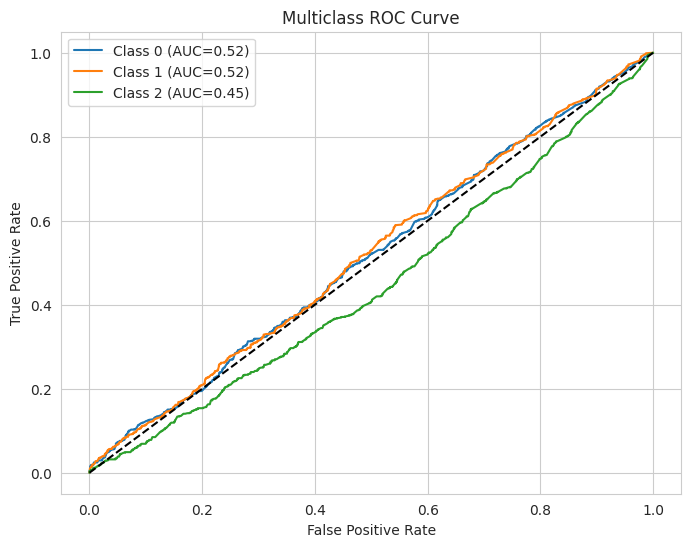


Decision Tree Accuracy: 0.32661808829832834


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# =====================================
# Copy Dataset
# =====================================

data = df.copy()

# =====================================
# Drop Unnecessary Columns
# =====================================

drop_cols = ["Date", "Athlete"]

for col in drop_cols:
    if col in data.columns:
        data.drop(columns=col, inplace=True)

# =====================================
# Fill Missing Values
# =====================================

data = data.ffill().bfill()

# =====================================
# Label Encoding
# =====================================

encoders = {}

for col in data.columns:

    if data[col].dtype == "object":

        le = LabelEncoder()

        data[col] = le.fit_transform(data[col].astype(str))

        encoders[col] = le

# =====================================
# Features & Target
# =====================================

X = data.drop("Medal", axis=1)

y = data["Medal"]

# =====================================
# Train Test Split
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================
# Random Forest
# =====================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

# =====================================
# ROC Curve (Multiclass)
# =====================================

classes = sorted(y.unique())

y_test_bin = label_binarize(y_test, classes=classes)

y_score = rf.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {classes[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multiclass ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# =====================================
# Decision Tree Accuracy
# =====================================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("\nDecision Tree Accuracy:",
      accuracy_score(y_test, pred_dt))

## Thanks...............Please Upvote